# Importing required libraries 

In [1]:
import torchvision.datasets as datasets
from torch.utils.data import TensorDataset, DataLoader
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as f 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Custom Neural Network Architecture 

In [2]:
class NeuralNetworkArchitecture(nn.Module):
    def __init__(self, input_size, output_size, hidden_layers=[150, 200, 300], init_type='xavier'):
        super(NeuralNetworkArchitecture, self).__init__()

        # Defining hidden layers
        self.layers = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        in_features = input_size        
        for h in hidden_layers:
            self.layers.append(nn.Linear(in_features, h))
            self.batch_norms.append(nn.BatchNorm1d(h))
            self.dropouts.append(nn.Dropout(p=0.2))
            in_features = h            

        # Output layer
        self.output = nn.Linear(in_features, output_size)

        # Initialize weights
        self.weights_initialization(init_type)

    # Forward pass using ReLU as activation function
    def forward(self, x):
        for layer, bn, dropout in zip(self.layers, self.batch_norms, self.dropouts):
            x = layer(x)       #linear transformation 
            x = bn(x)          #normalize output
            x = f.relu(x)      #apply ReLU activation
            x = dropout(x)     #creation of dropout layer
        x = self.output(x)      
        return x
 

    # Weight initialization
    def weights_initialization(self, init_type):
        all_layers = list(self.layers) + [self.output]
        for layer in all_layers:
            if isinstance(layer, nn.Linear):
                if init_type.lower() == 'xavier':
                    nn.init.xavier_uniform_(layer.weight)
                elif init_type.lower() == 'he':
                    nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.zeros_(layer.bias)


# Downloading MNIST Dataset

In [3]:
dataset = datasets.MNIST(root='./data', train=True, download=True)
x = dataset.data.numpy()
y = dataset.targets.numpy()
# Normalization
x = x / 255.0
# print(X_flat)
x_flat = x.reshape(-1, 28*28)
input_size = x_flat.shape[1]        
output_size = len(np.unique(y))


100%|██████████| 9.91M/9.91M [00:00<00:00, 64.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.68MB/s]


# Data splitting

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x_flat, y, test_size=0.4, stratify=y, random_state=3
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=3
)

In [5]:

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_val_t   = torch.tensor(x_val, dtype=torch.float32)
x_test_t  = torch.tensor(x_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset   = TensorDataset(x_val_t, y_val_t)
test_dataset  = TensorDataset(x_test_t, y_test_t)



# Batching function

In [6]:
def batching (train_dataset,val_dataset,test_dataset,batch_size=64):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size, shuffle=False)
    return train_loader , val_loader , test_loader 

# Model Training

In [7]:
def train_model(
    model, train_loader, val_loader, epochs=100, lr=0.01,
    wait_epochs=10,  # number of epochs to wait before early stopping
     device=None
):  
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # Store loss and accuracy for each epoch for later plotting
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_loss = float('inf')
    best_val_acc = float('inf')
    best_weights = model.state_dict() 
    epochs_no_improve = 0

    for epoch in range(epochs):
        # Training
        model.train()
        total_train_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model.forward(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * xb.size(0)
            y_pred = outputs.argmax(dim=1)
            correct += (y_pred == yb).sum().item()
            total += yb.size(0)

        train_loss = total_train_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        total_val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model.forward(xb)
                loss = criterion(outputs, yb)
                total_val_loss += loss.item() * xb.size(0)
                y_pred = outputs.argmax(dim=1)
                correct += (y_pred == yb).sum().item()
                total += yb.size(0)

        val_loss = total_val_loss / total
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(f"Epoch {epoch+1}:  "
        f"Train Loss: {train_loss:.4f} , Val Loss: {val_loss:.4f} , "
        f"Train Acc: {train_acc:.4f} , Val Acc: {val_acc:.4f}")

         
        # Early Stopping

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_weights = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= wait_epochs:
            print(f"\nEarly stopping at epoch {epoch+1}")
            model.load_state_dict(best_weights)
            break
    print(f"\n Val loss : {best_val_loss}")
    print(f"\n Val Acc : {best_val_acc}")
    return model, train_losses, val_losses, train_accs, val_accs


# Plotting function

In [8]:
def plotting(train_losses, val_losses, train_accs, val_accs):
    epochs = np.arange(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 5))

    # Loss plot 
    plt.subplot(2, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot 
    plt.subplot(2, 2, 2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

     #  Learning Curves with Error Bars
    train_losses_mean = np.array(train_losses)
    val_losses_mean = np.array(val_losses)
    train_losses_std = 0.02 * np.random.randn(len(train_losses))
    val_losses_std = 0.02 * np.random.randn(len(val_losses))

    plt.subplot(2, 2, 3)
    plt.errorbar(epochs, train_losses_mean, yerr=np.abs(train_losses_std),label='Train Loss - std')
    plt.errorbar( epochs,val_losses_mean, yerr=np.abs(val_losses_std), label='Val Loss - std')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Learning Curves with Error Bars")
    plt.legend()
    plt.grid(True)

    #  Convergence Analysis (difference between train and validation loss)
    diff = np.abs(np.array(val_losses) - np.array(train_losses))
    plt.subplot(2, 2, 4)
    plt.plot( epochs,diff)
    plt.xlabel("Epochs")
    plt.ylabel("Absolute Loss Difference")
    plt.title("Convergence Analysis")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


Epoch 1:  Train Loss: 0.8604 , Val Loss: 0.3519 , Train Acc: 0.7338 , Val Acc: 0.8964
Epoch 2:  Train Loss: 0.4271 , Val Loss: 0.2649 , Train Acc: 0.8706 , Val Acc: 0.9204
Epoch 3:  Train Loss: 0.3520 , Val Loss: 0.2136 , Train Acc: 0.8931 , Val Acc: 0.9342
Epoch 4:  Train Loss: 0.3064 , Val Loss: 0.1929 , Train Acc: 0.9076 , Val Acc: 0.9393
Epoch 5:  Train Loss: 0.2776 , Val Loss: 0.1773 , Train Acc: 0.9136 , Val Acc: 0.9433
Epoch 6:  Train Loss: 0.2547 , Val Loss: 0.1609 , Train Acc: 0.9237 , Val Acc: 0.9497
Epoch 7:  Train Loss: 0.2344 , Val Loss: 0.1534 , Train Acc: 0.9289 , Val Acc: 0.9520
Epoch 8:  Train Loss: 0.2242 , Val Loss: 0.1410 , Train Acc: 0.9310 , Val Acc: 0.9559
Epoch 9:  Train Loss: 0.2145 , Val Loss: 0.1348 , Train Acc: 0.9352 , Val Acc: 0.9577
Epoch 10:  Train Loss: 0.2052 , Val Loss: 0.1320 , Train Acc: 0.9367 , Val Acc: 0.9582
Epoch 11:  Train Loss: 0.1948 , Val Loss: 0.1273 , Train Acc: 0.9393 , Val Acc: 0.9600
Epoch 12:  Train Loss: 0.1846 , Val Loss: 0.1223 , T

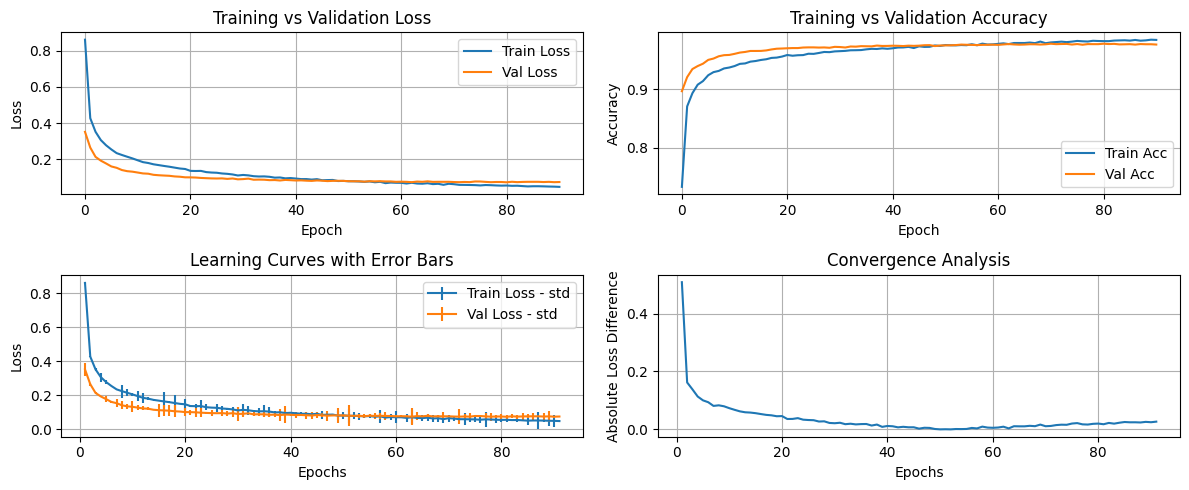

In [9]:
model = NeuralNetworkArchitecture(input_size, output_size)
train_loader,val_loader,test_loader = batching (train_dataset,val_dataset,test_dataset,batch_size=64)
model,train_losses, val_losses, train_accs, val_accs= train_model(model, train_loader, val_loader)
plotting(train_losses, val_losses, train_accs, val_accs)

# Hyper parameter analysis 

## Learning Rate Analysis


Training with Learning Rate = 0.1
Epoch 1:  Train Loss: 0.3965 , Val Loss: 0.1643 , Train Acc: 0.8788 , Val Acc: 0.9484
Epoch 2:  Train Loss: 0.2184 , Val Loss: 0.1253 , Train Acc: 0.9341 , Val Acc: 0.9590
Epoch 3:  Train Loss: 0.1776 , Val Loss: 0.1044 , Train Acc: 0.9464 , Val Acc: 0.9676
Epoch 4:  Train Loss: 0.1522 , Val Loss: 0.0995 , Train Acc: 0.9533 , Val Acc: 0.9693
Epoch 5:  Train Loss: 0.1331 , Val Loss: 0.0890 , Train Acc: 0.9587 , Val Acc: 0.9728
Epoch 6:  Train Loss: 0.1227 , Val Loss: 0.0904 , Train Acc: 0.9603 , Val Acc: 0.9722
Epoch 7:  Train Loss: 0.1115 , Val Loss: 0.0845 , Train Acc: 0.9652 , Val Acc: 0.9727
Epoch 8:  Train Loss: 0.1015 , Val Loss: 0.0847 , Train Acc: 0.9671 , Val Acc: 0.9749
Epoch 9:  Train Loss: 0.0910 , Val Loss: 0.0775 , Train Acc: 0.9709 , Val Acc: 0.9758
Epoch 10:  Train Loss: 0.0886 , Val Loss: 0.0786 , Train Acc: 0.9710 , Val Acc: 0.9765
Epoch 11:  Train Loss: 0.0838 , Val Loss: 0.0752 , Train Acc: 0.9734 , Val Acc: 0.9768
Epoch 12:  Train 

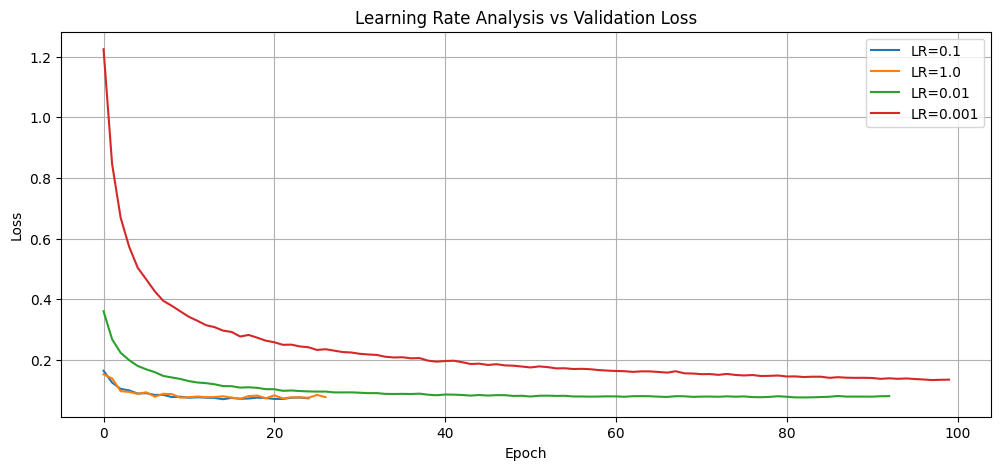

In [10]:
    results = {}
    lr_values = {0.001,0.01,0.1,1.0}
    for lr in lr_values:
        print(f"\nTraining with Learning Rate = {lr}")
        torch.manual_seed(55)
        model = NeuralNetworkArchitecture(input_size, output_size)
        model, train_losses, val_losses, train_accs, val_accs = train_model(
            model, train_loader, val_loader, lr=lr
        )
        results[lr] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }

    # Plot all learning curves together
    plt.figure(figsize=(12, 5))
    for lr, metrics in results.items():
        plt.plot(metrics["val_losses"], label=f"LR={lr}")
    plt.title("Learning Rate Analysis vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()



##  1. Convergence Analysis

- **LR = 0.1** → Gives the **fast convergence**, with a smooth loss drop and good final performance.  
- **LR = 0.01** → **Smoother**, but takes longer to reach similar accuracy.  
- **LR = 0.001** → Learning is very slow and wastes many epochs.  
- **LR = 1.0** → **Fast**.


##  2. Stability Analysis

- **LR = 0.1** → **Stable and fast**, reaches low loss smoothly.  
- **LR = 0.01** → **Very stable**, but slower to converge.  
- **LR = 0.001** → **Stable but too slow**, barely improving with each epoch.  
- **LR = 1.0** → **Least stable** , have some oscilations


## Batch Size Analysis


Training with Batch Size = 16 
Epoch 1:  Train Loss: 0.6167 , Val Loss: 0.2282 , Train Acc: 0.8044 , Val Acc: 0.9319
Epoch 2:  Train Loss: 0.3762 , Val Loss: 0.1818 , Train Acc: 0.8832 , Val Acc: 0.9427
Epoch 3:  Train Loss: 0.3119 , Val Loss: 0.1514 , Train Acc: 0.9030 , Val Acc: 0.9542
Epoch 4:  Train Loss: 0.2793 , Val Loss: 0.1336 , Train Acc: 0.9144 , Val Acc: 0.9591
Epoch 5:  Train Loss: 0.2500 , Val Loss: 0.1237 , Train Acc: 0.9221 , Val Acc: 0.9618
Epoch 6:  Train Loss: 0.2352 , Val Loss: 0.1192 , Train Acc: 0.9284 , Val Acc: 0.9627
Epoch 7:  Train Loss: 0.2187 , Val Loss: 0.1115 , Train Acc: 0.9333 , Val Acc: 0.9640
Epoch 8:  Train Loss: 0.2041 , Val Loss: 0.1059 , Train Acc: 0.9372 , Val Acc: 0.9666
Epoch 9:  Train Loss: 0.1986 , Val Loss: 0.1034 , Train Acc: 0.9373 , Val Acc: 0.9670
Epoch 10:  Train Loss: 0.1889 , Val Loss: 0.0972 , Train Acc: 0.9415 , Val Acc: 0.9695
Epoch 11:  Train Loss: 0.1772 , Val Loss: 0.0916 , Train Acc: 0.9451 , Val Acc: 0.9708
Epoch 12:  Train Los

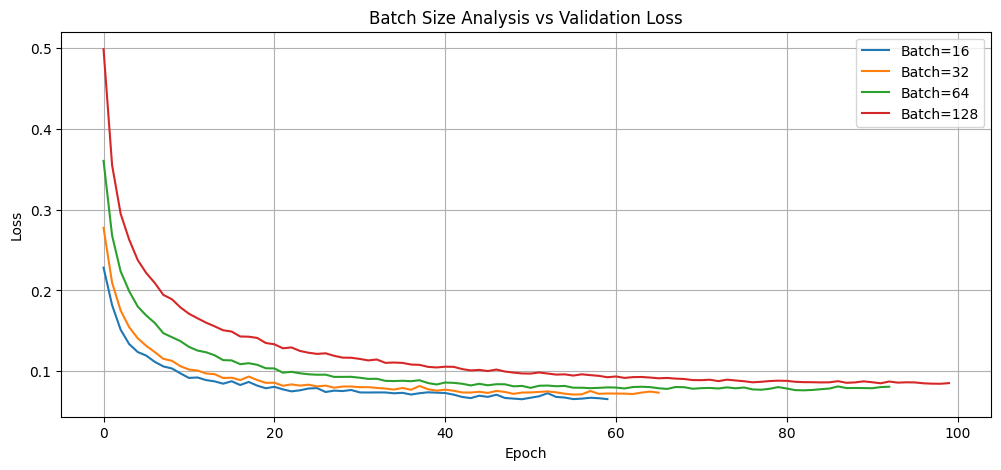

In [11]:
    results = {}
    batch_sizes = {16,32,64,128}
    for bs in batch_sizes:
        print(f"\nTraining with Batch Size = {bs} ")
        train_loader, val_loader, test_loader = batching(train_dataset, val_dataset, test_dataset, batch_size=bs)
        torch.manual_seed(55)
        model = NeuralNetworkArchitecture(input_size, output_size)
        model, train_losses, val_losses, train_accs, val_accs = train_model(
            model, train_loader, val_loader, lr=0.01
        )
        results[bs] = {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs
        }

    plt.figure(figsize=(12, 5))
    for bs, metrics in results.items():
        plt.plot(metrics["val_losses"], label=f"Batch={bs}")
    plt.title("Batch Size Analysis vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()



### Training Efficiency vs. Performance

| **Batch Size** | **Convergence** | **Final Validation Loss** | **Training Efficiency (per Time)** | **Generalization** |
|----------------|------------------------------------|----------------------------|------------------------------------|-----------------------------|
| **16**  | Fastest convergence | Lowest | Slowest | Best |
| **32**  | Very good | Very low | Moderate | Very good  | 
| **64**  | Medium | Slightly higher | Fast  | Good  |
| **128** | Slowest convergence | Highest | Fastest | Fair | 

### Gradient Noise Analysis

*  1.Small batches (16, 32) : Higher gradient noise ,more updates, better generalization.
*  2.Large batches (64, 128) : Low gradient noise ,more stable gradients ,faster,          smoother training but worse generalization.


## Architecture Analysis

In [12]:
def architecture_analysis(layer_counts, neuron_sizes, train_loader, val_loader, input_size, output_size):
    results = []

    for n_layers in layer_counts:
        for n_neurons in neuron_sizes:
            hidden_layers = [n_neurons] * n_layers
            print(f"\n{n_layers} hidden layers & {n_neurons} neurons ")
            torch.manual_seed(55)
            model = NeuralNetworkArchitecture(input_size, output_size, hidden_layers)
            model, train_losses, val_losses, train_accs, val_accs = train_model(
                model, train_loader, val_loader, epochs=30, lr=0.01
            )

            final_val_acc = val_accs[-1]
            best_val_loss = min(val_losses)
            results.append({
                "Hidden Layers": n_layers,
                "Neurons/Layer": n_neurons,
                "Final Val Acc": round(final_val_acc, 4),
                "Best Val Loss": round(best_val_loss, 4)
            })

    results_df = pd.DataFrame(results)
    return results_df


In [13]:
#ranges
layer_counts = [2, 3, 4, 5]
neuron_sizes = [64, 128, 256, 512]

archResults = architecture_analysis(layer_counts, neuron_sizes, train_loader, val_loader, input_size, output_size)

display(archResults.sort_values(by="Final Val Acc", ascending=False))



2 hidden layers & 64 neurons 
Epoch 1:  Train Loss: 1.3333 , Val Loss: 0.7417 , Train Acc: 0.5950 , Val Acc: 0.8317
Epoch 2:  Train Loss: 0.7587 , Val Loss: 0.5157 , Train Acc: 0.7939 , Val Acc: 0.8736
Epoch 3:  Train Loss: 0.5963 , Val Loss: 0.4173 , Train Acc: 0.8375 , Val Acc: 0.8925
Epoch 4:  Train Loss: 0.5138 , Val Loss: 0.3639 , Train Acc: 0.8564 , Val Acc: 0.9024
Epoch 5:  Train Loss: 0.4627 , Val Loss: 0.3269 , Train Acc: 0.8682 , Val Acc: 0.9107
Epoch 6:  Train Loss: 0.4327 , Val Loss: 0.3024 , Train Acc: 0.8746 , Val Acc: 0.9146
Epoch 7:  Train Loss: 0.4016 , Val Loss: 0.2839 , Train Acc: 0.8836 , Val Acc: 0.9188
Epoch 8:  Train Loss: 0.3828 , Val Loss: 0.2689 , Train Acc: 0.8887 , Val Acc: 0.9216
Epoch 9:  Train Loss: 0.3649 , Val Loss: 0.2552 , Train Acc: 0.8938 , Val Acc: 0.9246
Epoch 10:  Train Loss: 0.3529 , Val Loss: 0.2454 , Train Acc: 0.8977 , Val Acc: 0.9272
Epoch 11:  Train Loss: 0.3398 , Val Loss: 0.2384 , Train Acc: 0.8989 , Val Acc: 0.9274
Epoch 12:  Train Loss

,Hidden Layers,Neurons/Layer,Final Val Acc,Best Val Loss
7,3,512,0.9709,0.0904
11,4,512,0.9706,0.0902
15,5,512,0.9694,0.0973
3,2,512,0.9678,0.0980
10,4,256,0.9675,0.1097
6,3,256,0.9663,0.1037
14,5,256,0.9661,0.1096
2,2,256,0.9647,0.1107
9,4,128,0.9609,0.1239
5,3,128,0.9608,0.1278
